# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seed
seed = 42

# 1. Local Files

## 1) Basic

In [2]:
# Load
path = 'samples/titanic.csv'
df = pd.read_csv(
    path,

    # Columns
    names=None,                                 # column names.
    header='infer',                             # the row index for header.
    usecols=['sex', 'survived'],                # cols to read.
    dtype={'survived': bool},                   # dtypes.
    converters={'sex': lambda x: x.lower()},    # converters.
    
    # Rows
    nrows=20,               # read n rows.
    skiprows=range(1, 6),   # skip the first n rows.
    # skipfooter=3,           # skip the last n rows. NOT supported together with `nrows`.

    # Null
    na_values={'survived': 'Unknown'},      # values to consider as None.
    na_filter=True,                         # if there is no null values, turn off to improve the performance.

    # Etc
    encoding='utf-8-sig',       # encoding for text fields.
    encoding_errors='strict',   # how encoding errors are handled.
    memory_map=True,            # directly maps into the memory.
)

# Save
save_path = 'samples/sample.csv'
df.to_csv(save_path, index=False)

- Note) If both `dtype` and `converters` are specified, only `converters` is applied.
- Note) Use `skipheader=range(1, 6)` instead `skipheader=5` to keep the header.

## 2) Large Files

In [3]:
path = 'samples/titanic.csv.zip'      # compress.
df = pd.read_csv(
    path,
    usecols=['survived'],   # use only necessary columns.
    nrows=100,              # read only how much needed.
    compression='infer',    # on-the-fly decompression.
    iterator=True,          # return iterator instead a full df.
    chunksize=10,           # return a part at once.
    low_memory=True,        # use a subset for dtype inference.
    na_filter=False,        # turn off if not exist.
    memory_map=True,        # map into virtual RAM, useful for local files.
)

# Iterator: dynamic size
with pd.read_csv(path, iterator=True) as reader:
    batch = reader.get_chunk(64)   # when free.
    ...
    batch = reader.get_chunk(32)    # when busy.

# Chunksize: fixed size
df_chunks = pd.read_csv(path, chunksize=64)
for df in df_chunks:
    print(df.shape)
    break

(64, 14)


## 3) Datetime

In [4]:
path = 'samples/birthday.csv'
df = pd.read_csv(
    path,
    parse_dates=['Birthday'],           # datetime cols.
    date_format='%Y-%m-%d %H:%M:%S',    # datetime format.
)

- Note) Specifying a non-datetime column to `parse_dates` do NOT raise any error.

## 4) Extensions

### .xlsx

In [5]:
# %pip install openpyxl

# Load
path = 'samples/sample.xlsx'
df = pd.read_excel(
    path,
    engine='openpyxl',          # should specify an engine.
    sheet_name=["titanic"]      # sheet name.
)

# Save
df['titanic'].to_excel(
    path,
    index=False,
    sheet_name="titanic"
)

### .pkl

In [6]:
# Load
path = 'samples/sample.pkl'
df = pd.read_pickle(path)

# Save
df.to_pickle(path)

### .json

In [7]:
# Load
path = 'samples/sample.json'
df = pd.read_json(
    path,
    orient='columns',       # `split` | `records` | `index` | `columns` | `values` | `table`.
    typ='frame',            # `series` | `frame`.
    encoding='utf-8',
    lines=True,             # should be True for using `nrows` or `chunksize`.
    nrows=5,
    # chunksize=1,
)

# Normalize
df_norm = pd.json_normalize(df['survived'])
display(df['survived'])
display(df_norm)

# Save
df.to_json(path)

0    {'0': {'0': {'0': {'0': 1, '1': 1, '2': 0, '3'...
Name: survived, dtype: object

,0.0.0.0,0.0.0.1,0.0.0.2,0.0.0.3,0.0.0.4,0.0.0.5,0.0.0.6,0.0.0.7,0.0.0.8,0.0.0.9,...,0.0.0.90,0.0.0.91,0.0.0.92,0.0.0.93,0.0.0.94,0.0.0.95,0.0.0.96,0.0.0.97,0.0.0.98,0.0.0.99
0,1,1,0,0,0,1,1,0,1,0,...,1,1,1,1,1,1,0,1,1,1


### clipboard

In [8]:
path = 'samples/sample.pkl'
df = pd.read_pickle(path)

# Load
df.to_clipboard()

# Save
pd.read_clipboard().shape

(5, 12)

# 2. API

## 1) sklearn.datasets

### loader and fetcher

| Index | Name         | n_samples | n_features | Type        | API                          | Description                                                           | Notes                                                                                                                                                                                                                       |
|------:|--------------|----------:|------------|-------------|------------------------------|-----------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 1     | Iris         | 150       | 4          | clf (3)     | `load_iris()`                | Classification on flower types.                                       | Equal class distribution (1/3).                                                                                                                                                                                             |
| 2     | Diabetes     | 442       | 10         | reg         | `load_diabetes()`            | Diabetes-related measurements -> diabetes progression after 1 year.   | Collected only by diabetes.<br>Features are scaled to $x' = \frac{(x - \mu)}{\sigma * \sqrt n}$.                                                                                                                            |
| 3     | Wine         | 178       | 13         | clf (3)     | `load_wine()`                | Classification on wine types.                                         |                                                                                                                                                                                                                             |
| 4     | BreastCancer | 569       | 30         | clf (2)     | `load_breast_cancer()`       | Diagnosis on breast cancer.                                           | 212/569.                                                                                                                                                                                                                    |
| 5     | Olivetti     | 400       | 64x64      | clf (40)    | `fetch_olivetti_faces()`     | 10 facial images x 40 subjects.                                       | Quantized to 256 grey levels and scaled to [0, 1].<br>Taken between 1992.4 ~ 1994.4.<br>Few samples for each class -> could be more interesting from unsupervised or semi-supervised perspective.                               |
| 6     | News20       | 18,846    | Text       | clf (20)    | `fetch_20newsgroups()`       | Classification on news topics.                                        | Train/test split by specific date.<br>Vectorized dataset is provided by `fetch_20newsgroups_vectorized()`.<br>Remove metadata by `remove=('headers', 'footers', 'quotes')`.                                                   |
| 7     | LFW          | 13,233    | 5,828      | clf (5,749) | `fetch_lfw_people()`         | A single face image, centered, of famous people. From Kaggle, `lfw-dataset`. | For pairs data, `fetch_lfw_pairs()`.                                                                                                                                                                                        |
| 8     | CovType      | 581,012   | 54         | clf (7)     | `fetch_covtype()`            | Classification on forest covertypes, i.e. the dominant species of tree. |                                                                                                                                                                                                                             |
| 9     | RCV1         | 804,414   | 47,236     | clf (103)   | `fetch_rcv1()`               | Classification on news topics.                                        | 23,149/781,265 train/test samples.<br>Sparse matrix (0.16%).                                                                                                                                                                |
| 10    | Housing      | 20,640    | 8          | reg         | `fetch_california_housing()` | Prediction on the house price.                                        | Collected from 1990 U.S. census.<br>A median of block group.                                                                                                                                                                |

In [9]:
from sklearn.datasets import load_iris

X, y = load_iris(
    return_X_y=True,    # exclude additional info like DESCR.
    as_frame=True,      # pd.DataFrame().
)

X.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


### `load_sample_image`

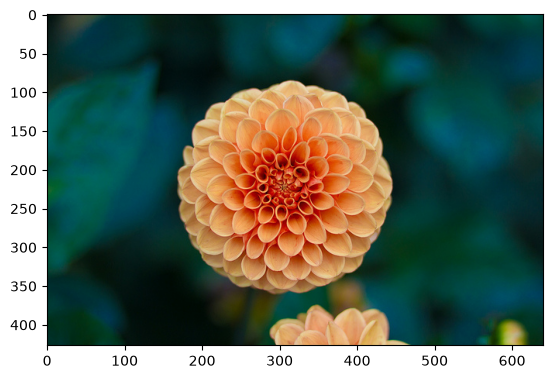

In [10]:
from sklearn.datasets import load_sample_image

img = load_sample_image('flower.jpg')   # or 'china.jpg'.

plt.imshow(img)

### `fetch_openml`
- https://www.openml.org/

In [11]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("titanic", version=1, return_X_y=True)

X.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"


## 2) kaggle

In [12]:
import os
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi
import kagglehub

# Token
token_path = Path.home() / ".kaggle" / "access_token"
os.environ["KAGGLE_API_TOKEN"] = token_path.read_text().strip()

# Auth
api = KaggleApi()
api.authenticate()

# Load
path = Path('../data/titanic')
if not Path(path).is_dir():
    kagglehub.competition_download(
        handle='titanic',      # last term in url, e.g. kaggle.com/competitions/titanic.
        output_dir=path,
    )

c:\Users\yana\Desktop\Library\AI\ai-summary\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) datasets

In [13]:
from datasets import load_dataset

ds = load_dataset('stanfordnlp/imdb')

ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

# 3. Synthetic Generation

## Single Label

### `make_blobs`

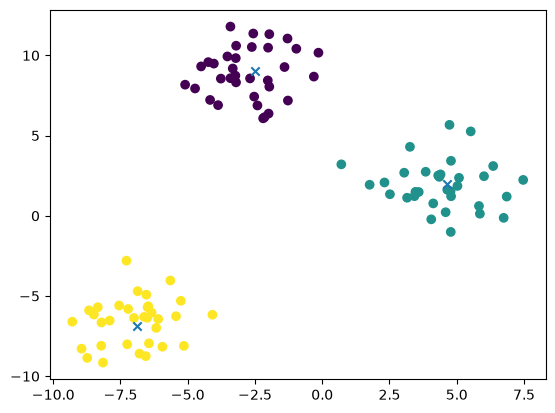

In [14]:
from sklearn.datasets import make_blobs

X, y, centers = make_blobs(
    n_samples=100,              # int | array-like. per cluster.
    n_features=2,               # n_features.
    centers=3,                  # n_classes.
    center_box=(-10.0, 10.0),   # a bounding box for center positions.
    cluster_std=1.5,            # float | array-like.
    shuffle=True,
    random_state=seed,
    return_centers=True,
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(centers[:, 0], centers[:, 1], marker='x')

### `make_classification`

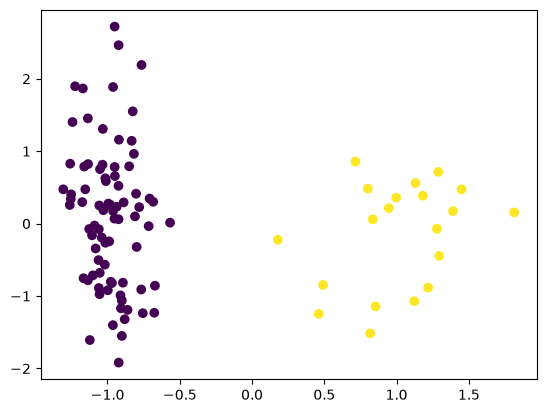

In [15]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,              # per class.
    n_features=2,
    n_classes=2,
    weights=[0.8, 0.2],         # None -> balanced.

    n_clusters_per_class=1,
    hypercube=True,
    class_sep=1.0,              # multiply the hypercube size.
    shift=0.0,                  # or array-like.
    scale=1.0,                  # or array-like.

    n_informative=1,
    n_redundant=0,              # a linear combination of informatives, with random params.
    n_repeated=0,               # a copy of informative or redundant, randomly selected.
    flip_y=1e-2,                # a fraction of random classes.

    return_X_y=True,
    shuffle=True,
    random_state=seed,
)

plt.scatter(X[:, 0], X[:, 1], c=y)

### `make_regression`

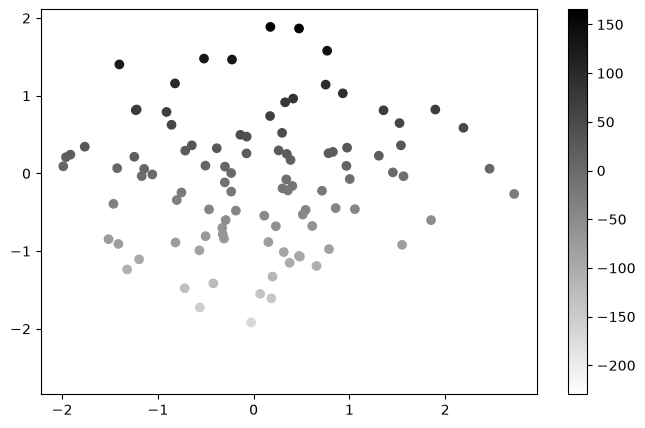

In [16]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,              # per class.
    n_features=2,
    n_targets=1,
    n_informative=1,

    shuffle=True,
    random_state=seed,
)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='grey_r')
plt.colorbar(scatter)

### `make_gaussian_quantiles`

- Divides a single Gaussian cluster into near-equal-size, by concentric hyperspheres.

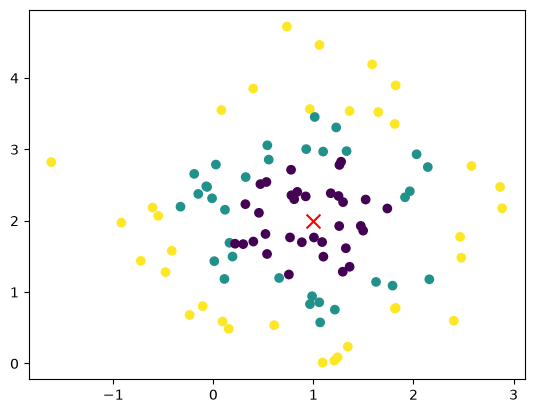

In [ ]:
from sklearn.datasets import make_gaussian_quantiles

X, y = make_gaussian_quantiles(
    n_samples=100,
    n_features=2,
    n_classes=3,

    mean=(1.0, 2.0),
    cov=1.0,

    shuffle=True,
    random_state=seed,
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter([1.0], [2.0], marker='x', s=100, color='red')

### `make_circles`

- A large circle containing a small circle in 2d.

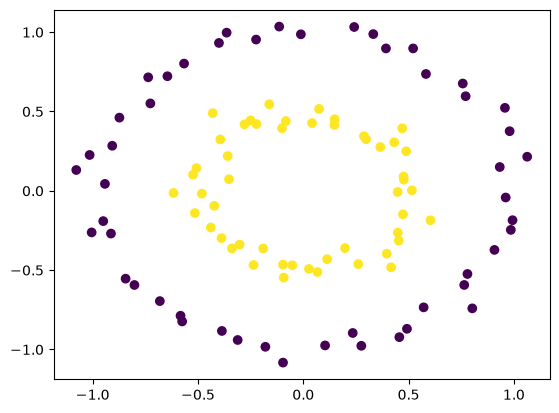

In [ ]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=100,
    factor=0.5,     # large vs small.
    noise=0.05,     # std of Gaussian noise.

    shuffle=True,
    random_state=seed,
)

plt.scatter(X[:, 0], X[:, 1], c=y)

### `make_moons`

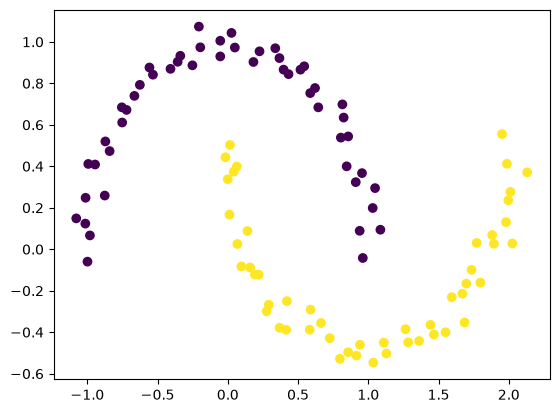

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=100,
    noise=0.05,     # std of Gaussian noise.

    shuffle=True,
    random_state=seed,
)

plt.scatter(X[:, 0], X[:, 1], c=y)

## Multi Label

### `make_multilabel_classification`

In [ ]:
from sklearn.datasets import make_multilabel_classification

X, y = make_multilabel_classification(
    n_samples=100,                  # per class.
    n_features=2,
    n_classes=5,
    n_labels=2,                     # average number of active labels.

    allow_unlabeled=True,           # if True, some samples might not belong to any class.
    sparse=False,                   # if True, return a sparse matrix for features.

    return_indicator='dense',
    return_distributions=False,

    random_state=seed,
)

y[:5]

array([[0, 0, 1, 0, 0],
       [1, 0, 1, 1, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [1, 1, 1, 1, 1]])

## Biclustering

### `make_biclusters`

```markdown
             Column group 0   Column group 1
Row group 0       block 0          empty
Row group 1       empty            block 1
```

(10, 10)
(2, 10)
(2, 10)


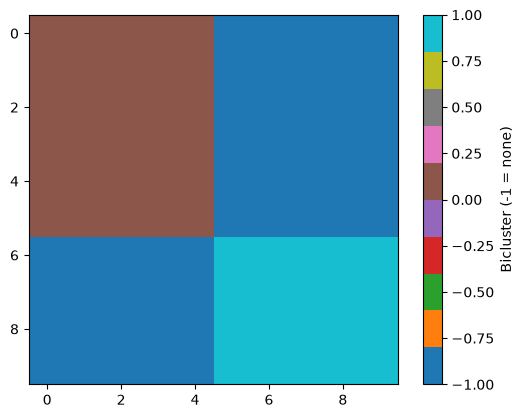

In [ ]:
from sklearn.datasets import make_biclusters

X, rows, cols = make_biclusters(
    shape=(10, 10),       # shape of features.
    n_clusters=2,
    noise=0.05,         # std of Gaussian noise.
    minval=10,
    maxval=100,

    shuffle=False,
    random_state=seed,
)

print(X.shape)        # features.
print(rows.shape)     # membership of rows.
print(cols.shape)     # membership of columns.

k, i = 0, 1
rows[k, i]          # if True, a row i belongs to bicluster k.
cols[k, i]          # if True, a col i belongs to bicluster k.

membership = np.full(X.shape, -1)

for k in range(len(rows)):
    membership[np.ix_(rows[k], cols[k])] = k

plt.imshow(membership, cmap="tab10")
plt.colorbar(label="Bicluster (-1 = none)")
plt.show()

### `make_checkerboard`

```markdown
             Column group 0   Column group 1
Row group 0       block 0          block 1
Row group 1       block 2          block 3
```

(10, 10)
(9, 10)
(9, 10)


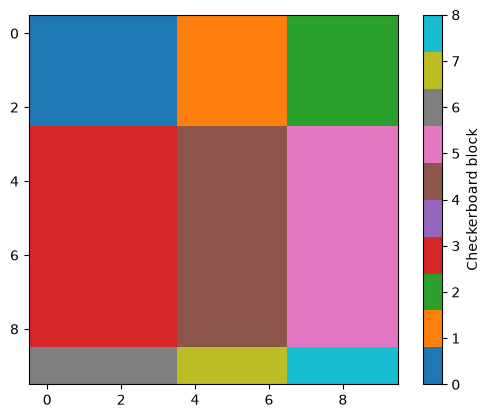

In [ ]:
from sklearn.datasets import make_checkerboard

X, rows, cols = make_checkerboard(
    shape=(10, 10),       # shape of features.
    n_clusters=(3, 3),
    noise=0.05,         # std of Gaussian noise.
    minval=10,
    maxval=100,

    shuffle=False,
    random_state=seed,
)

print(X.shape)        # features.
print(rows.shape)     # membership of rows.
print(cols.shape)     # membership of columns.

k, i = 0, 1
rows[k, i]          # if True, a row i belongs to bicluster k.
cols[k, i]          # if True, a col i belongs to bicluster k.

membership = np.argmax(rows[:, :, None] & cols[:, None, :], axis=0)

plt.imshow(membership, cmap="tab10")
plt.colorbar(label="Checkerboard block")
plt.show()

## Manifold

### `make_s_curve`

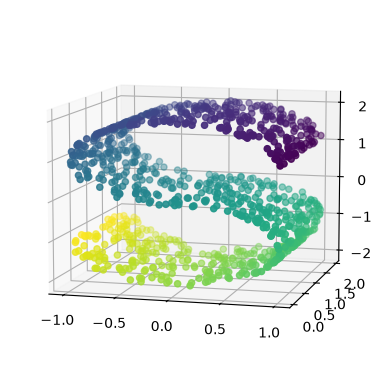

In [ ]:
from sklearn.datasets import make_s_curve

X, t = make_s_curve(n_samples=1_000, noise=0.0, random_state=seed)

ax = plt.figure().add_subplot(projection='3d')
ax.view_init(elev=9, azim=-75)
ax.scatter(*X.T, c=t)

### `make_swiss_roll`

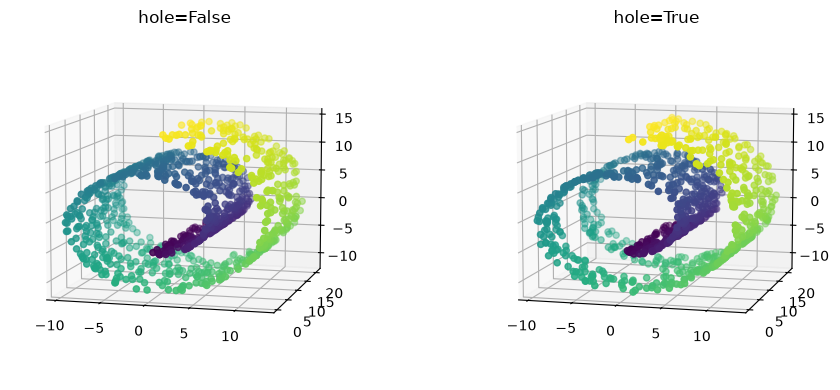

In [ ]:
from sklearn.datasets import make_swiss_roll

X, t = make_swiss_roll(
    n_samples=1_000,
    noise=0.0,
    random_state=seed,
)

fig = plt.figure(figsize=(10, 4))

for i, hole in enumerate([False, True], 1):
    X, t = make_swiss_roll(
        n_samples=1_000,
        noise=0.0,
        hole=hole,
        random_state=seed,
    )

    ax = fig.add_subplot(1, 2, i, projection="3d")
    ax.view_init(elev=9, azim=-75)
    ax.scatter(*X.T, c=t)
    ax.set_title(f"hole={hole}")

plt.tight_layout()

## Decomposition

### `make_low_rank_matrix`

- A matrix that can be efficiently represented a few singular vectors.

In [ ]:
from sklearn.datasets import make_low_rank_matrix

data = make_low_rank_matrix(
    n_samples=100,
    n_features=100,
    effective_rank=10,
    tail_strength=0.5,          # [0, 1].

    random_state=seed,
)
data.shape

(100, 100)

### `make_sparse_coded_signal`

- data = dictionary @ code.

In [ ]:
from sklearn.datasets import make_sparse_coded_signal

data, dictionary, code = make_sparse_coded_signal(
    n_samples=10,
    n_components=3,
    n_features=2,
    n_nonzero_coefs=2,

    random_state=seed,
)

### `make_spd_matrix`

- Symmetric positive definite matrix.

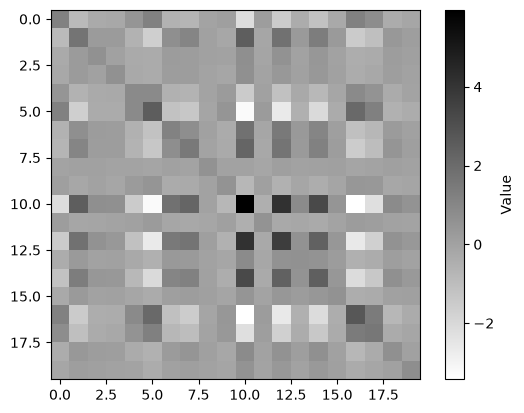

In [ ]:
from sklearn.datasets import make_spd_matrix

spd = make_spd_matrix(
    n_dim=20,
    random_state=seed,
)

matrix = plt.imshow(spd, cmap='grey_r')
plt.colorbar(matrix, label='Value')

### `make_sparse_spd_matrix`

- Sparse SPD.

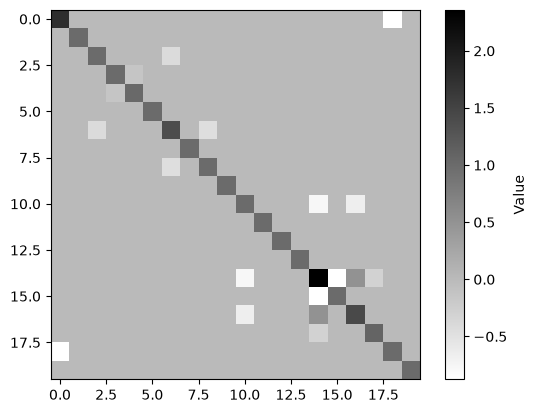

In [28]:
from sklearn.datasets import make_sparse_spd_matrix

spd = make_sparse_spd_matrix(
    n_dim=20,
    alpha=0.95,             # higher alpha -> more sparse.
    norm_diag=False,        # if True, normalizes so that all diagonal elements are 1.

    smallest_coef=0.1,
    largest_coef=0.9,

    sparse_format=None,     # dense ndarray. Can be `csc`, `csr`, etc.
    random_state=42,
)

matrix = plt.imshow(spd, cmap='grey_r')
plt.colorbar(matrix, label='Value')